# RAMIFY — Version 2 (ETF sectoriels) · la version intégrable Ramify

> **Suite directe de `RAMIFY_V1_actions.ipynb`.** Le brief : *« Pour chaque ticker déclaré, on substitue
> l'ETF sectoriel correspondant via le mapping GICS. Un achat de NVDA devient un achat de XLK. La logique
> d'entrée et de sortie reste strictement identique, seul l'instrument change. C'est cette version qui
> s'intègre à l'univers d'investissement habituel de Ramify. »*
>
> On reprend **exactement la même sélection annuelle** (Sharpe rétréci de la série de trades + UCB + filtre
> commissions) ; on remplace seulement chaque action par son **ETF SPDR sectoriel**, puis on mesure la
> **dilution V1 → V2**. *(Recherche au-delà de la demande → `SUPP_C_approfondissement_V2`.)*


In [1]:
import sys, os, warnings; warnings.filterwarnings('ignore')
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = os.path.join(base, '00. S3S4 en cours')
    if os.path.exists(os.path.join(p, 'data.py')): S3 = p; break
sys.path.insert(0, S3); os.chdir(S3)
import numpy as np, pandas as pd
import data, prices, portfolio, evaluate, selection
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4.2)
def ann_stats(daily):
    d = daily.dropna(); yrs = len(d)/252
    return {'CAGR':(1+d).prod()**(1/yrs)-1,'vol':d.std()*np.sqrt(252),
            'sharpe':d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan,
            'maxDD':((1+d).cumprod()/(1+d).cumprod().cummax()-1).min()}
def bench_daily(price, idx): return price.reindex(idx).ffill().pct_change().fillna(0.0)
def fmt(df, index=True):
    pct={'CAGR','vol','maxDD','alpha_vs_SPY','alpha_FF','alpha','dilution'}; ratio={'sharpe','t','beta'}
    f={}
    for c in df.columns:
        if c in pct: f[c]=lambda x:f'{x:+.2%}'
        elif c in ratio: f[c]=lambda x:f'{x:.2f}'
        elif c in {'K','n_pos','n'}: f[c]=lambda x:f'{int(x):d}'
    return df.to_string(index=index, formatters=f)
print('moteur importé depuis :', S3)

moteur importé depuis : /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours


## 1. Données + sélection (identique à la V1)

On recharge le journal, on calcule la série de trades réalisés (`with_realized`) et on **rejoue la même
sélection annuelle** que `RAMIFY_V1` (K=6 pour l'illustration ; grille en §4).

In [2]:
df = data.load_transactions(2014, 2026)
buys = selection.with_realized(data.buy_signals(df).copy(), df,
                               prices.load_panel(sorted(data.buy_signals(df)['ticker'].dropna().unique())),
                               prices.get_spy(), horizon_months=12)
panel = prices.load_panel(sorted(buys['ticker'].dropna().unique()))
spy = prices.get_spy(); factors = prices.get_factors()
com = selection.load_committees()
K = 6
sels = selection.selections_by_year(buys, com, K=K)
pos = portfolio.build_positions(selection.gate_buys(buys, sels), df, horizon_months=12)
print(f"sélection K={K} rejouée → {len(pos)} positions V1 (mêmes membres/années que RAMIFY_V1)")

sélection K=6 rejouée → 1391 positions V1 (mêmes membres/années que RAMIFY_V1)


## 2. Substitution GICS → ETF SPDR sectoriel (brief)

`selection.ticker_to_etf` mappe chaque ticker à son **secteur GICS** (calculé en Semaine 2, colonne
`sector_gics` des tables FINAL) puis à l'**ETF SPDR** correspondant. *Point-in-time : XLRE existe depuis
2015, XLC depuis 2018 — borné/documenté.* La logique entrée/sortie reste **strictement identique**.

In [3]:
t2e = selection.ticker_to_etf()
ex = [('NVDA',), ('AAPL',), ('JPM',), ('PFE',), ('XOM',)]
print("Exemples de substitution (ticker → ETF sectoriel) :")
for (tk,) in ex:
    if tk in t2e: print(f"  {tk:5s} → {t2e[tk]}")
etfp = prices.load_panel(["XLE","XLB","XLI","XLY","XLP","XLV","XLF","XLK","XLC","XLU","XLRE","RSP","AGG"])
pos_v2 = selection.to_v2(pos, t2e)
print(f"\nV1 {len(pos)} positions → V2 {len(pos_v2)} mappées (perte {1-len(pos_v2)/len(pos):.0%} : "
      f"tickers sans secteur GICS dans les FINAL — ex. non cotés US)")
print(f"ETF distincts utilisés : {sorted(pos_v2['ticker'].unique())}")

Exemples de substitution (ticker → ETF sectoriel) :


  NVDA  → XLK
  AAPL  → XLK
  JPM   → XLF
  PFE   → XLV
  XOM   → XLE

V1 1391 positions → V2 1295 mappées (perte 7% : tickers sans secteur GICS dans les FINAL — ex. non cotés US)
ETF distincts utilisés : ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


## 3. Walk-forward V2 vs benchmarks + dilution V1 → V2 (K=6)

Même moteur, **nets de 20 bps**. On compare V1 (actions) et V2 (ETF) à SPY ; la **dilution** = ce que la
substitution sectorielle retire (ou ajoute) à l'alpha factoriel.

Walk-forward K=6 — V1 vs V2 vs SPY :
              CAGR     vol sharpe   maxDD alpha_vs_SPY
V1 actions  +9.40% +22.19%   0.52 -47.83%       -4.73%
V2 ETF      +6.02% +15.80%   0.45 -37.88%       -8.11%
SPY        +14.13% +16.99%   0.86 -33.72%       +0.00%



Alpha FF-Carhart  V1 : +0.72%/an (t=0.14, beta 0.79)
Alpha FF-Carhart  V2 : -3.79%/an (t=-1.51, beta 0.74)
DILUTION V1→V2 (alpha) : -4.51%/an → la substitution sectorielle EFFACE le gain idiosyncratique (l'edge est firm-specific).


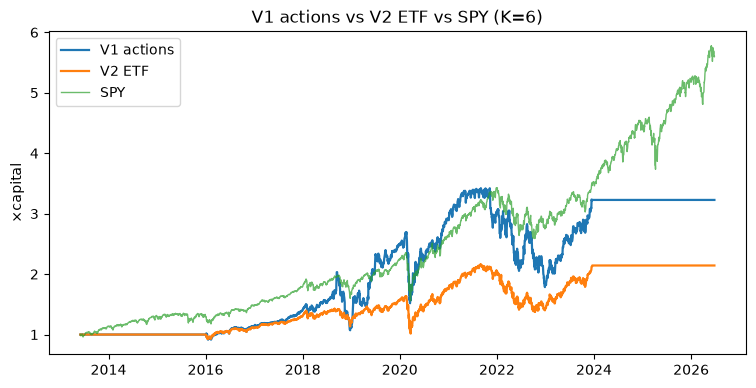

In [4]:
d_v1 = portfolio.run_portfolio(pos,    panel, weighting='size', cost_bps=20)['net']
d_v2 = portfolio.run_portfolio(pos_v2, etfp,  weighting='size', cost_bps=20)['net']
idx = d_v1.index; b_spy = bench_daily(spy, idx)
tbl = pd.DataFrame({'V1 actions':ann_stats(d_v1),'V2 ETF':ann_stats(d_v2),'SPY':ann_stats(b_spy)}).T
tbl['alpha_vs_SPY'] = tbl['CAGR'] - ann_stats(b_spy)['CAGR']
print(f"Walk-forward K={K} — V1 vs V2 vs SPY :"); print(fmt(tbl))
fa1, fa2 = evaluate.factor_alpha(d_v1, factors), evaluate.factor_alpha(d_v2, factors)
print(f"\nAlpha FF-Carhart  V1 : {fa1['alpha_annuel']:+.2%}/an (t={fa1['alpha_t']:.2f}, beta {fa1['beta_marche']:.2f})")
print(f"Alpha FF-Carhart  V2 : {fa2['alpha_annuel']:+.2%}/an (t={fa2['alpha_t']:.2f}, beta {fa2['beta_marche']:.2f})")
print(f"DILUTION V1→V2 (alpha) : {fa2['alpha_annuel']-fa1['alpha_annuel']:+.2%}/an "
      f"→ la substitution sectorielle EFFACE le gain idiosyncratique (l'edge est firm-specific).")

for lab,d in [('V1 actions',d_v1),('V2 ETF',d_v2)]:
    plt.plot((1+d).cumprod().index,(1+d).cumprod(),label=lab,lw=1.6)
plt.plot(idx,(1+b_spy).cumprod(),label='SPY',lw=1,alpha=.7)
plt.legend(); plt.title(f'V1 actions vs V2 ETF vs SPY (K={K})'); plt.ylabel('×capital'); plt.show()

## 4. Grille K ∈ {4,6,8,10} — dilution V1 → V2 à chaque K

In [5]:
rows = []
for K_ in [4,6,8,10]:
    s = selection.selections_by_year(buys, com, K=K_)
    p1 = portfolio.build_positions(selection.gate_buys(buys, s), df, horizon_months=12)
    p2 = selection.to_v2(p1, t2e)
    dd1 = portfolio.run_portfolio(p1, panel, weighting='size', cost_bps=20)['net']
    dd2 = portfolio.run_portfolio(p2, etfp,  weighting='size', cost_bps=20)['net']
    a1, a2 = evaluate.factor_alpha(dd1, factors), evaluate.factor_alpha(dd2, factors)
    rows.append({'K':K_,'V1_sharpe':ann_stats(dd1)['sharpe'],'V1_alpha':a1['alpha_annuel'],
                 'V2_sharpe':ann_stats(dd2)['sharpe'],'V2_alpha':a2['alpha_annuel'],
                 'dilution':a2['alpha_annuel']-a1['alpha_annuel']})
G = pd.DataFrame(rows)
fdict={'K':lambda x:f'{int(x):d}','V1_sharpe':lambda x:f'{x:.2f}','V2_sharpe':lambda x:f'{x:.2f}',
       'V1_alpha':lambda x:f'{x:+.2%}','V2_alpha':lambda x:f'{x:+.2%}','dilution':lambda x:f'{x:+.2%}'}
print(G.to_string(index=False, formatters=fdict))
print("\nÀ chaque K : V2 a un Sharpe plus BAS et un alpha plus FAIBLE/négatif que V1 → la dilution sectorielle")
print("est systématique. La V2 n'est pas de l'alpha : c'est un BETA sectoriel dé-risqué (vol/DD réduits).")

 K V1_sharpe V1_alpha V2_sharpe V2_alpha dilution
 4      0.56   +1.74%      0.42   -3.91%   -5.65%
 6      0.52   +0.72%      0.45   -3.79%   -4.51%
 8      0.71   +3.97%      0.58   -1.77%   -5.74%
10      0.68   +3.66%      0.58   -2.10%   -5.76%

À chaque K : V2 a un Sharpe plus BAS et un alpha plus FAIBLE/négatif que V1 → la dilution sectorielle
est systématique. La V2 n'est pas de l'alpha : c'est un BETA sectoriel dé-risqué (vol/DD réduits).


## 5. Métriques niveau-trade V2 + lecture

In [6]:
tr2 = evaluate.trade_returns(pos_v2, etfp, spy)
st = evaluate.trade_stats(tr2)
print("Métriques niveau-trade — V2 (ETF) :")
for k,v in st.items(): print(f"  {k:16s}: {v:+.3f}" if isinstance(v,float) else f"  {k:16s}: {v}")
print("\nLecture : en passant à l'ETF, la distribution se resserre (moins d'extrêmes) — cohérent avec un")
print("instrument diversifié. Le hit-rate monte un peu mais la magnitude par trade chute → pas d'alpha net.")

Métriques niveau-trade — V2 (ETF) :
  n               : 1246
  hit_rate        : +0.480
  avg_win         : +0.068
  avg_loss        : -0.085
  profit_factor   : +0.742
  esperance_abn   : -0.011
  mediane_abn     : -0.002

Lecture : en passant à l'ETF, la distribution se resserre (moins d'extrêmes) — cohérent avec un
instrument diversifié. Le hit-rate monte un peu mais la magnitude par trade chute → pas d'alpha net.


## 6. Cadrage produit + synthèse V2

**Ce que la V2 EST.** Un **beta « Congrès » sectoriel, dé-risqué** : drawdown et volatilité plus faibles que
la V1, alpha factoriel ≈ 0 / négatif, Sharpe sous celui de SPY. La substitution ETF **retire l'information
idiosyncratique** (firm-specific) qui portait le maigre signal de la V1 — c'est mécaniquement attendu et
mesuré ici à chaque K.

**Pourquoi c'est quand même *livrable*.** C'est exactement le positionnement des ETF réels **NANC / KRUZ**
(~1 Md$ d'encours cumulés) : on ne vend **pas** une promesse de battre le marché, on vend de la
**transparence + un récit + une exposition thématique** intégrable au catalogue d'ETF de Ramify. La décision
est **commerciale** (distribution / narratif), pas une thèse d'alpha.

**Ce que la V2 N'EST PAS.** Un générateur d'alpha : aucun K ne bat SPY en risque-ajusté, et la dilution
V1→V2 est systématique.

→ Le détail « le Sharpe de la V2 mène-t-il quelque part ? » (caractérisation fine + variante pilotée par la
*breadth* d'achat + loi fondamentale de Grinold-Kahn) est traité dans **`SUPP_C_approfondissement_V2.ipynb`**.
Recommandation consolidée dans **`NOTE_RECHERCHE_QIS.md`**.